# Bayesian hyperparameter search for learning the MET Efficiency space

In [1]:
import sys 
sys.path.append("../..")  # TODO: update with package install

import gpder
from gpder import plot_gpr
from gpder import GPKernelDerAware, GPKernel
from gpder import GaussianProcessRegressor
from gpder import BayesianOptimization

import uproot 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.stats as st
import pandas as pd

from numpy.linalg import det

from sklearn.metrics import mean_squared_error

from scipy.special import expit  # used in steep sigmoid

Read the three-momenta of the jets from "three_jets.root"

Only the momenta of the events with the pT cuts j1_pt>200 and j2_pt<200 are kept.

In [2]:
f = uproot.open("./three_jets.root")
tree = f['tnt']

njets = np.array(tree['nj'])
njets_cut = np.where(njets<4)

j1_threeM = np.stack((np.array(tree['j1_pt'])[njets_cut], 
                      np.array(tree['j1_eta'])[njets_cut], 
                      np.array(tree['j1_phi'])[njets_cut]), axis=1)
j2_threeM = np.stack((np.array(tree['j2_pt'])[njets_cut], 
                      np.array(tree['j2_eta'])[njets_cut], 
                      np.array(tree['j2_phi'])[njets_cut]), axis=1)
j3_threeM = np.stack((np.array(tree['j3_pt'])[njets_cut], 
                      np.array(tree['j3_eta'])[njets_cut], 
                      np.array(tree['j3_phi'])[njets_cut]), axis=1)

f.close()

### Efficiency of MET < 50 

The function Eff_MET50_sigmoid below calculates the efficiency of the events with MET<50, given the photon and jet scale as the nuisance parameters.

The function dEff_MET50_sigmoid calculates the gradient of the efficiency with respect to the nuisance parameters.  

To have a differentiable function of the efficiency, a sigmoid function is used to approximaate the efficiency cuts. 

In [3]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))


In [4]:
def Eff_MET50(J_scale, j_scale, 
              j1_threeM=j1_threeM, j2_threeM=j2_threeM, j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            if met < 50:
                count_met += 1
            
    return count_met / count_pTcut
    

In [5]:
def Eff_MET50_sigmoid(J_scale, j_scale, 
                      j1_threeM=j1_threeM, 
                      j2_threeM=j2_threeM, 
                      j3_threeM=j3_threeM):
    count_met = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            count_met += sigmoid(-(met-50.0))

    return count_met / count_pTcut


In [6]:
def dEff_MET50_sigmoid(J_scale, j_scale, 
              j1_threeM=j1_threeM, j2_threeM=j2_threeM, j3_threeM=j3_threeM):
    dmet_dj1 = 0
    dmet_dj2j3 = 0
    count_pTcut = 0
    for i in range(len(j1_threeM)):
        # -- pT -- # 
        j1_pt = j1_threeM[i, 0] / J_scale
        j2_pt = j2_threeM[i, 0] / j_scale
        j3_pt = j3_threeM[i, 0] / j_scale
        if (j1_pt > 200 and j2_pt  < 200):
            count_pTcut += 1
            # -- pT_x decomp -- # 
            j1_pt_x = j1_pt * np.cos(j1_threeM[i, 2])
            j2_pt_x = j2_pt * np.cos(j2_threeM[i, 2])
            j3_pt_x = j3_pt * np.cos(j3_threeM[i, 2])
            # -- pT_y decomp -- #
            j1_pt_y = j1_pt * np.sin(j1_threeM[i, 2])
            j2_pt_y = j2_pt * np.sin(j2_threeM[i, 2])
            j3_pt_y = j3_pt * np.sin(j3_threeM[i, 2])
            # -- MET -- #
            met_x = j1_pt_x + j2_pt_x + j3_pt_x
            met_y = j1_pt_y + j2_pt_y + j3_pt_y
            met = np.sqrt(met_x * met_x + met_y * met_y)

            dsig = -dsigmoid(-(met-50.0))
            dmet = 0.5 / met

            # wrt J_scale 
            dj1  = -2*met_x*j1_threeM[i, 0] * np.cos(j1_threeM[i, 2]) / J_scale**2
            dj1 += -2*met_y*j1_threeM[i, 0] * np.sin(j1_threeM[i, 2]) / J_scale**2
            # wrt j_scale
            dj2j3  = -2*met_x*j2_threeM[i, 0] * np.cos(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_x*j3_threeM[i, 0] * np.cos(j3_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j2_threeM[i, 0] * np.sin(j2_threeM[i, 2]) / j_scale**2
            dj2j3 += -2*met_y*j3_threeM[i, 0] * np.sin(j3_threeM[i, 2]) / j_scale**2

            dmet_dj1   += dsig * dmet * dj1
            dmet_dj2j3 += dsig * dmet * dj2j3

    return [dmet_dj1 / count_pTcut, dmet_dj2j3 / count_pTcut]


In [7]:
def plot_true_table(f):
    nu_J = [0.9, 1.0, 1.1]
    nu_j = [0.9, 1.0, 1.1]
    
    cells = []
    for j in nu_J:
        for J in nu_J:
            eff = f(J, j)
            cells.append("{:0.3f}".format(eff))
    cells = np.array(cells).reshape(3, 3)
            
    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']
    
    fig, ax = plt.subplots()
    ax.set_axis_off()

    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']

    table = ax.table(cellText=cells,
                     rowLabels=rowLabels,
                     colLabels=colLabels,
                     cellLoc='center',
                     loc='upper left')
    table.set_fontsize(16)
    table.scale(2, 2)
    plt.text(0.08, 1.05, "Efficiency of MET < 50  -- Sig approx", fontsize=16)
    plt.savefig("true_eff_sig", bbox_inches="tight")
    plt.show()

#plot_true_table(Eff_MET50_sigmoid)


In [8]:
def plot_relative_table(f):
    nu_J = [0.9, 1.0, 1.1]
    nu_j = [0.9, 1.0, 1.1]
    
    cells = []
    for j in nu_J:
        for J in nu_J:
            eff = f(J, j) / f(1.0, 1.0)
            cells.append("{:0.3f}".format(eff))
    cells = np.array(cells).reshape(3, 3)
            
    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']
    
    fig, ax = plt.subplots()
    ax.set_axis_off()

    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']

    table = ax.table(cellText=cells,
                     rowLabels=rowLabels,
                     colLabels=colLabels,
                     cellLoc='center',
                     loc='upper left')
    table.set_fontsize(16)
    table.scale(2, 2)
    plt.text(0.08, 1.05, "Efficiency of MET < 50, relative to (1, 1)  -- Sig approx", fontsize=16)
    plt.savefig("rel_eff_sig", bbox_inches="tight")
    plt.show()

#plot_relative_table(Eff_MET50_sigmoid)


In [9]:
def plot_offaxis_table(f):
    nu_J = [0.9, 1.0, 1.1]
    nu_j = [0.9, 1.0, 1.1]
    
    cells = []
    for j in nu_J:
        for J in nu_J:
            if (J==1.0 or j==1.0):
                eff = f(J, j) / f(1.0, 1.0)
            else:
                eff = f(J, 1.0) * f(1.0, j) / f(1.0, 1.0)**2
            cells.append("{:0.3f}".format(eff))
    cells = np.array(cells).reshape(3, 3)
            
    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']
    
    fig, ax = plt.subplots()
    ax.set_axis_off()

    colLabels = [r'$\nu_J=0.9$', r'$\nu_J=1.0$', r'$\nu_J=1.1$']
    rowLabels = [r'$\nu_j=0.9$', r'$\nu_j=1.0$', r'$\nu_j=1.1$']

    table = ax.table(cellText=cells,
                     rowLabels=rowLabels,
                     colLabels=colLabels,
                     cellLoc='center',
                     loc='upper left')
    table.set_fontsize(16)
    table.scale(2, 2)
    plt.text(0.08, 1.05, "Off-axis estimated efficiency of MET < 50  -- Sig approx", fontsize=16)
    plt.savefig("est_eff_sig", bbox_inches="tight")
    plt.show()

#plot_offaxis_table(Eff_MET50_sigmoid)


### Regressing the MET space

We can learn to regress the MET space by using Gaussian Process Regression (GPR).

Starting with five training points, we compare the GPR with and without derivative information. 

In [10]:
# -- training points -- # 
nu_a_train = [0.9, 1.0, 1.0, 1.0, 1.1]
nu_j_tain = [1.0, 0.9, 1.0, 1.1, 1.0]
X_train = np.vstack((nu_a_train, nu_j_tain)).T

y_train = np.array([Eff_MET50(X_train[i][0], X_train[i][1]) for i in range(len(X_train))])
y_train_sig = np.array([Eff_MET50_sigmoid(X_train[i][0], X_train[i][1]) for i in range(len(X_train))])
dy_train_sig = np.array([dEff_MET50_sigmoid(X_train[i][0], X_train[i][1]) for i in range(len(X_train))])


# -- testing points -- # 
res=10
X_lower = 0.5 
X_upper = 1.5
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET50(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])
y_test_sig = np.array([Eff_MET50_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])



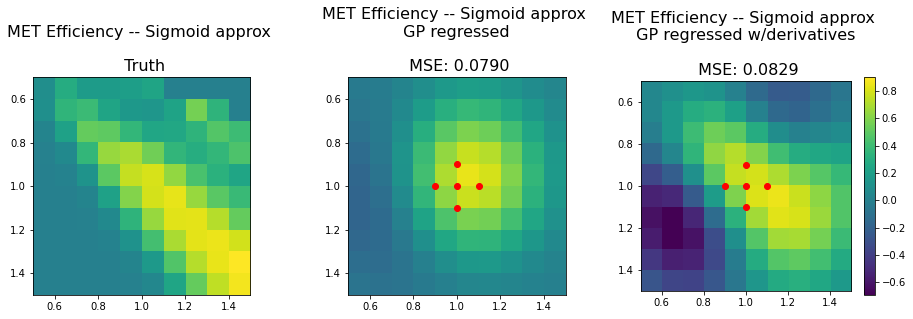

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
ax = axs.ravel()

# ----- Regular GP ----- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train_sig)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test_sig)

# -- Now with derivatives -- #
kernel = GPKernelDerAware()
gp_der = GaussianProcessRegressor(kernel=kernel,
                                  n_restarts_optimizer=10, 
                                  random_state=123)
gp_der.fit(X=X_train, y=y_train_sig, dy=dy_train_sig)
mu_der, cov_der = gp_der.predict(X=X_test, return_cov=True)
mse_der = mean_squared_error(mu_der, y_test_sig)

# -- plots -- # 
max_val = np.max(np.concatenate((y_test_sig, mu, mu_der)))
min_val = np.min(np.concatenate((y_test_sig, mu, mu_der)))

axs[0].set_title("MET Efficiency -- Sigmoid approx \n \n Truth", fontsize=16)
axs[0].imshow(y_test_sig.reshape(res, res), 
              origin='upper', 
              extent=[0.5, 1.5, 1.5, 0.5], 
              vmin=min_val, vmax=max_val)

axs[1].set_title("MET Efficiency -- Sigmoid approx \n GP regressed \n \n MSE: {:0.4f}".format(mse),
                 fontsize=16)
axs[1].imshow(mu.reshape(res, res), 
              origin='upper', 
              extent=[0.5, 1.5, 1.5, 0.5],
              vmin=min_val, vmax=max_val)
axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

axs[2].set_title("MET Efficiency -- Sigmoid approx \n GP regressed w/derivatives \n \n MSE: {:0.4f}".format(mse_der),
                 fontsize=16)
im = axs[2].imshow(mu_der.reshape(res, res), 
                   origin='upper', 
                   extent=[0.5, 1.5, 1.5, 0.5],
                   vmin=min_val, vmax=max_val)
axs[2].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)
fig.colorbar(im)


plt.savefig("GP_regression", bbox_inches="tight")


In [27]:
mu_sq = mu.reshape(10, 10)

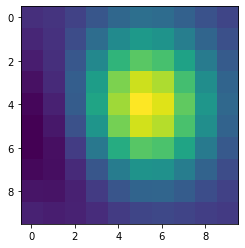

In [28]:
plt.imshow(mu_sq)

In [29]:
mu_sq[9, 9]

0.0009663982052915687

In [33]:
y_test_sig_sq = y_test_sig.reshape(10, 10)

In [39]:
mu_sq[9, 9]

0.0009663982052915687

In [40]:
y_test_sig_sq[9, 9]

0.8712082079873824

In [41]:
(0.8712082079873824 - 0.0009663982052915687)**2

0.7573208074928088

### Using Bayes search to reduce the uncertainty of the GP regression

Now, we can use a bayes search to sample the space at the locations with high uncertainty. 

| Iter | J_scale   | j_scale   | Target    | Uncert     |
| 0    | 0.900000  | 1.000000  | 0.580745  | 0.000000   |
| 1    | 1.000000  | 0.900000  | 0.787183  | 0.000000   |
| 2    | 1.000000  | 1.000000  | 0.780826  | 0.000000   |
| 3    | 1.000000  | 1.100000  | 0.661358  | 0.000000   |
| 4    | 1.100000  | 1.000000  | 0.834261  | 0.000000   |
| 6    | 1.500000  | 1.500000  | 0.871208  | 0.184885   |
| 7    | 0.500000  | 1.500000  | 0.000000  | 0.064419   |
| 8    | 0.500000  | 0.500000  | 0.095242  | 0.048969   |
| 9    | 1.500000  | 0.500000  | 0.000000  | 0.059510   |
| 10   | 0.500000  | 1.000000  | 0.000036  | 0.056096   |
| 11   | 1.500000  | 1.000000  | 0.302570  | 0.046220   |
| 12   | 1.000000  | 0.500000  | 0.157781  | 0.069875   |
| 13   | 1.000000  | 1.500000  | 0.016822  | 0.070190   |
| 14   | 0.689411  | 1.310588  | 0.000915  | 0.033670   |
| 15   | 1.312296  | 0.687706  | 0.313560  | 0.026041   |


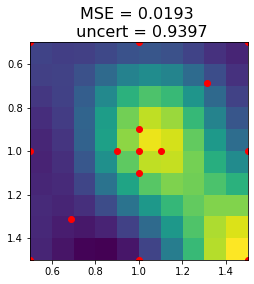

In [12]:
bayes = BayesianOptimization(fun=Eff_MET50_sigmoid,
                             param_bounds={'J_scale': (0.5, 1.5),
                                           'j_scale': (0.5, 1.5)},
                             random_state=123)

bayes.minimize_uncertainty(params_init=X_train, n_iters=10)

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
plt.imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
plt.title("MSE = {:0.4f} \n uncert = {:0.4f}".format(mse, np.trace(cov)), fontsize=16)
plt.plot(bayes.params[:, 0], bayes.params[:, 1], "r.", ms=12)
plt.show()

| Iter | J_scale   | j_scale   | Target    | Uncert     |
| 0    | 0.900000  | 1.000000  | 0.580745  | 0.000000   |
| 1    | 1.000000  | 0.900000  | 0.787183  | 0.000000   |
| 2    | 1.000000  | 1.000000  | 0.780826  | 0.000000   |
| 3    | 1.000000  | 1.100000  | 0.661358  | 0.000000   |
| 4    | 1.100000  | 1.000000  | 0.834261  | 0.000000   |
| 6    | 0.500000  | 0.500000  | 0.095242  | 0.333711   |
| 7    | 1.500000  | 0.500000  | 0.000000  | 0.192184   |
| 8    | 0.500000  | 1.500000  | 0.000000  | 0.131621   |
| 9    | 1.500000  | 1.500000  | 0.871208  | 0.095780   |
| 10   | 1.000000  | 0.500000  | 0.157781  | 0.077741   |
| 11   | 0.500000  | 1.000152  | 0.000034  | 0.071602   |
| 12   | 1.500000  | 1.000196  | 0.303178  | 0.062491   |
| 13   | 1.000000  | 1.500000  | 0.016822  | 0.060133   |
| 14   | 1.284754  | 0.715377  | 0.342089  | 0.011186   |
| 15   | 0.686854  | 1.313347  | 0.000784  | 0.012429   |


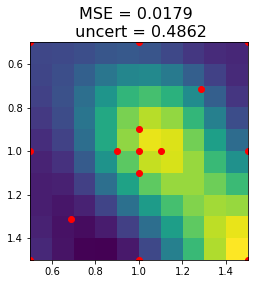

In [13]:
bayes = BayesianOptimization(fun=Eff_MET50_sigmoid,
                             dfun=dEff_MET50_sigmoid,
                             param_bounds={'J_scale': (0.5, 1.5),
                                           'j_scale': (0.5, 1.5)},
                             random_state=123)

bayes.minimize_uncertainty(params_init=X_train, n_iters=10)

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
plt.imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
plt.title("MSE = {:0.4f} \n uncert = {:0.4f}".format(mse, np.trace(cov)), fontsize=16)
plt.plot(bayes.params[:, 0], bayes.params[:, 1], "r.", ms=12)
plt.show()

In [15]:
mean_squared_error(np.ones_like(mu)*0.5, y_test_sig)

0.11609184136307846